# CIC-IDS2017 -- Feature and Data Quality Analysis

## Objectives

- Detect missing values
- Detect infinite values
- Analyze duplicate records
- Identify constant and near-constant features
- Examine feature statistics and skewness
- Check schema consistency across dataset files
- Identify highly correlated feature pairs
- Produce a consolidated feature-quality report

> This notebook is diagnostic only. No features are removed or transformed here.

## 1. Imports and Configurations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

In [3]:
DATA_DIR = Path("../data/raw/cicids2017")
OUTPUT_DIR = Path("../results")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

csv_files = sorted(DATA_DIR.glob("*.csv"))

len(csv_files), csv_files

(8,
 [WindowsPath('../data/raw/cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'),
  WindowsPath('../data/raw/cicids2017/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'),
  WindowsPath('../data/raw/cicids2017/Friday-WorkingHours-Morning.pcap_ISCX.csv'),
  WindowsPath('../data/raw/cicids2017/Monday-WorkingHours.pcap_ISCX.csv'),
  WindowsPath('../data/raw/cicids2017/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv'),
  WindowsPath('../data/raw/cicids2017/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'),
  WindowsPath('../data/raw/cicids2017/Tuesday-WorkingHours.pcap_ISCX.csv'),
  WindowsPath('../data/raw/cicids2017/Wednesday-workingHours.pcap_ISCX.csv')])

## 2. Load Dataset

In [4]:
dfs = {}

for file in csv_files:
    print(f"Loading: {file.name}")
    dfs[file.name] = pd.read_csv(file, low_memory=False)

print("\nLoaded files:", len(dfs))

Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv

Loaded files: 8


In [5]:
for name, df in dfs.items():
    print(f"{name}: {df.shape}")

Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: (225745, 79)
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: (286467, 79)
Friday-WorkingHours-Morning.pcap_ISCX.csv: (191033, 79)
Monday-WorkingHours.pcap_ISCX.csv: (529918, 79)
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: (288602, 79)
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: (170366, 79)
Tuesday-WorkingHours.pcap_ISCX.csv: (445909, 79)
Wednesday-workingHours.pcap_ISCX.csv: (692703, 79)


## 3. Schema Consistency

In [7]:
reference_columns = set(next(iter(dfs.values())).columns)

schema_report = []

for name, df in dfs.items():
    columns = set(df.columns)

    schema_report.append({
        "file": name,
        "num_columns": len(df.columns),
        "missing_columns": len(reference_columns - columns),
        "extra_columns": len(columns - reference_columns),
        "column_order_matches": list(df.columns) == list(next(iter(dfs.values())).columns)
    })

schema_df = pd.DataFrame(schema_report)

schema_df

,file,num_columns,missing_columns,extra_columns,column_order_matches
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,79,0,0,True
1,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,79,0,0,True
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,79,0,0,True
3,Monday-WorkingHours.pcap_ISCX.csv,79,0,0,True
4,Thursday-WorkingHours-Afternoon-Infilteration....,79,0,0,True
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,79,0,0,True
6,Tuesday-WorkingHours.pcap_ISCX.csv,79,0,0,True
7,Wednesday-workingHours.pcap_ISCX.csv,79,0,0,True


In [8]:
schema_df[
    (schema_df["missing_columns"] > 0) |
    (schema_df["extra_columns"] > 0) |
    (~schema_df["column_order_matches"])
]

,file,num_columns,missing_columns,extra_columns,column_order_matches


In [9]:
for name, df in dfs.items():
    print(f"\n{name}")
    print(df.dtypes.value_counts())


Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
int64      54
float64    24
str         1
Name: count, dtype: int64

Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
int64      54
float64    24
str         1
Name: count, dtype: int64

Friday-WorkingHours-Morning.pcap_ISCX.csv
int64      54
float64    24
str         1
Name: count, dtype: int64

Monday-WorkingHours.pcap_ISCX.csv
int64      54
float64    24
str         1
Name: count, dtype: int64

Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
int64      54
float64    24
str         1
Name: count, dtype: int64

Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
int64      54
float64    24
str         1
Name: count, dtype: int64

Tuesday-WorkingHours.pcap_ISCX.csv
int64      54
float64    24
str         1
Name: count, dtype: int64

Wednesday-workingHours.pcap_ISCX.csv
int64      54
float64    24
str         1
Name: count, dtype: int64


## 4. Missing and Infinite Values

In [21]:
data = pd.concat(dfs.values(), ignore_index=True)
data.columns = data.columns.str.strip()

print(data.columns[-5:])
print("Dataset Shape:", data.shape)

Index(['Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min', 'Label'], dtype='str')
Dataset Shape: (2830743, 79)


### Missing Values

In [22]:
missing = data.isna().sum()

missing_summary = (
    pd.DataFrame({
        "missing_count": missing,
        "missing_percentage": missing / len(data) * 100
    })
    
    .sort_values("missing_count", ascending = False)
)

missing_summary.head(20)

,missing_count,missing_percentage
Flow Bytes/s,1358,0.0480
Flow Duration,0,0.0000
Destination Port,0,0.0000
Total Backward Packets,0,0.0000
Total Length of Fwd Packets,0,0.0000
Total Length of Bwd Packets,0,0.0000
Total Fwd Packets,0,0.0000
Fwd Packet Length Max,0,0.0000
Fwd Packet Length Min,0,0.0000
Fwd Packet Length Std,0,0.0000


### Infinite Values

In [23]:
numeric_cols = data.select_dtypes(include=np.number).columns

inf_counts = np.isinf(data[numeric_cols]).sum()

inf_summary = (
    pd.DataFrame({
        "inf_count": inf_counts,
        "inf_percentage": inf_counts / len(data) * 100
    })
    .sort_values("inf_count", ascending=False)
)

inf_summary.head(20)

,inf_count,inf_percentage
Flow Packets/s,2867,0.1013
Flow Bytes/s,1509,0.0533
Total Fwd Packets,0,0.0000
Total Backward Packets,0,0.0000
Destination Port,0,0.0000
Flow Duration,0,0.0000
Fwd Packet Length Max,0,0.0000
Fwd Packet Length Min,0,0.0000
Fwd Packet Length Mean,0,0.0000
Fwd Packet Length Std,0,0.0000


In [24]:
missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_percentage
Flow Bytes/s,1358,0.0480


In [25]:
inf_summary[inf_summary["inf_count"] > 0]

,inf_count,inf_percentage
Flow Packets/s,2867,0.1013
Flow Bytes/s,1509,0.0533


In [45]:
suspicious_features = [
    "Fwd Header Length",
    "Fwd Header Length.1",
    "Bwd Header Length",
    "min_seg_size_forward"
]

data[suspicious_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Fwd Header Length,2830743.0000,-25997.3920,21052857.8732,-32212234632.0000,40.0000,64.0000,120.0000,4644908.0000
Fwd Header Length.1,2830743.0000,-25997.3920,21052857.8732,-32212234632.0000,40.0000,64.0000,120.0000,4644908.0000
Bwd Header Length,2830743.0000,-2273.2753,1452208.9396,-1073741320.0000,20.0000,40.0000,104.0000,5838440.0000
min_seg_size_forward,2830743.0000,-2741.6879,1084989.3838,-536870661.0000,20.0000,24.0000,32.0000,138.0000


In [46]:
for col in suspicious_features:
    print(f"\n{col}")
    print(
        data.loc[
            data[col] < 0,
            ["Label", col]
        ].sort_values(col).head(10)
    )


Fwd Header Length
          Label  Fwd Header Length
1693398  BENIGN       -32212234632
1692423  BENIGN        -9663668122
2084431  BENIGN        -6442447920
2026346  BENIGN        -6442447920
1693399  BENIGN        -4831831506
2020404  BENIGN        -2147482640
703392   BENIGN        -1929349973
1974966  BENIGN        -1073741320
1984167  BENIGN        -1073741320
1973379  BENIGN        -1073741320

Fwd Header Length.1
          Label  Fwd Header Length.1
1693398  BENIGN         -32212234632
1692423  BENIGN          -9663668122
2084431  BENIGN          -6442447920
2026346  BENIGN          -6442447920
1693399  BENIGN          -4831831506
2020404  BENIGN          -2147482640
703392   BENIGN          -1929349973
1974966  BENIGN          -1073741320
1984167  BENIGN          -1073741320
1973379  BENIGN          -1073741320

Bwd Header Length
          Label  Bwd Header Length
1974966  BENIGN        -1073741320
1984167  BENIGN        -1073741320
1973379  BENIGN        -1073741320
1692414  

In [47]:
for col in suspicious_features:
    print(
        col,
        "negative values:",
        (data[col] < 0).sum(),
        f"({(data[col] < 0).mean() * 100:.4f}%)"
    )

Fwd Header Length negative values: 35 (0.0012%)
Fwd Header Length.1 negative values: 35 (0.0012%)
Bwd Header Length negative values: 22 (0.0008%)
min_seg_size_forward negative values: 35 (0.0012%)


## 5. Duplicate Analysis

### Exact duplicate rows

In [26]:
duplicate_count = data.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", duplicate_count / len(data) * 100)

Duplicate rows: 308381
Duplicate percentage: 10.893994968812075


### Check duplicates by label

In [ ]:
[label for label in data.columns if "label" in label.lower()]

[' Label']

In [27]:
duplicate_by_label = (
    data[data.duplicated(keep=False)]
    .groupby("Label")
    .size()
    .sort_values(ascending=False)
)

duplicate_by_label

Label
BENIGN                      236257
PortScan                    101501
DoS Hulk                     59564
SSH-Patator                   2826
FTP-Patator                   2457
DoS slowloris                  507
DoS Slowhttptest               323
Web Attack � Brute Force        62
DDoS                            20
Bot                             19
DoS GoldenEye                   14
dtype: int64

In [44]:
duplicate_rows = data[data.duplicated(keep=False)]

duplicate_summary = (
    duplicate_rows
    .groupby(data.columns.tolist())
    .size()
    .sort_values(ascending=False)
)

print("Number of duplicate groups:", len(duplicate_summary))
print("Rows involved in duplicate groups:", len(duplicate_rows))

Number of duplicate groups: 95150
Rows involved in duplicate groups: 403550


## 6. Constant and near-constant features

### Constant features

In [28]:
unique_counts = data.nunique(dropna=False).sort_values()

constant_features = unique_counts[unique_counts == 1]

print("Constant features:", len(constant_features))
constant_features

Constant features: 8


Bwd PSH Flags           1
Fwd Avg Bulk Rate       1
Bwd Avg Bytes/Bulk      1
Bwd Avg Packets/Bulk    1
Fwd Avg Packets/Bulk    1
Fwd Avg Bytes/Bulk      1
Bwd Avg Bulk Rate       1
Bwd URG Flags           1
dtype: int64

### Near-constant features

In [31]:
near_constant = []

for col in data.columns:
    top_frequency = data[col].value_counts(normalize=True, dropna=False).iloc[0]

    if top_frequency >= 0.999:
        near_constant.append({
            "feature": col,
            "dominant_value_frequency": top_frequency
        })

near_constant_df = pd.DataFrame(near_constant)
near_constant_df

,feature,dominant_value_frequency
0,Bwd PSH Flags,1.0000
1,Fwd URG Flags,0.9999
2,Bwd URG Flags,1.0000
3,RST Flag Count,0.9998
4,CWE Flag Count,0.9999
5,ECE Flag Count,0.9998
6,Fwd Avg Bytes/Bulk,1.0000
7,Fwd Avg Packets/Bulk,1.0000
8,Fwd Avg Bulk Rate,1.0000
9,Bwd Avg Bytes/Bulk,1.0000


## 7. Statistical Feature Analysis

### Numerical features

In [32]:
numeric_data = data.select_dtypes(include=np.number)

stats = numeric_data.describe().T

stats["skewness"] = numeric_data.skew()

stats.sort_values("skewness", key=abs, ascending=False).head(20)

c:\Coding Stuff\CIC-Dataset-Analysis\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Coding Stuff\CIC-Dataset-Analysis\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Coding Stuff\CIC-Dataset-Analysis\.venv\Lib\site-packages\pandas\core\nanops.py:1275: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


,count,mean,std,min,25%,50%,75%,max,skewness
Fwd Header Length.1,2830743.0000,-25997.3920,21052857.8732,-32212234632.0000,40.0000,64.0000,120.0000,4644908.0000,-1325.0738
Fwd Header Length,2830743.0000,-25997.3920,21052857.8732,-32212234632.0000,40.0000,64.0000,120.0000,4644908.0000,-1325.0738
Total Length of Fwd Packets,2830743.0000,549.3024,9993.5892,0.0000,12.0000,62.0000,187.0000,12900000.0000,805.5705
Subflow Fwd Bytes,2830743.0000,549.2919,9980.0702,0.0000,12.0000,62.0000,187.0000,12870338.0000,803.5986
Bwd Header Length,2830743.0000,-2273.2753,1452208.9396,-1073741320.0000,20.0000,40.0000,104.0000,5838440.0000,-717.0313
min_seg_size_forward,2830743.0000,-2741.6879,1084989.3838,-536870661.0000,20.0000,24.0000,32.0000,138.0000,-474.5353
act_data_pkt_fwd,2830743.0000,5.4182,636.4257,0.0000,0.0000,1.0000,2.0000,213557.0000,284.5952
Subflow Bwd Packets,2830743.0000,10.3938,997.3883,0.0000,1.0000,2.0000,4.0000,291922.0000,244.6795
Total Backward Packets,2830743.0000,10.3938,997.3883,0.0000,1.0000,2.0000,4.0000,291922.0000,244.6795
Subflow Fwd Packets,2830743.0000,9.3612,749.6728,1.0000,2.0000,2.0000,5.0000,219759.0000,244.3806


### Zero-dominated features

In [33]:
zero_percentage = (
    (numeric_data == 0).sum() / len(numeric_data) * 100
).sort_values(ascending=False)

zero_percentage.head(20)

Bwd Avg Bulk Rate      100.0000
Bwd Avg Packets/Bulk   100.0000
Fwd Avg Bytes/Bulk     100.0000
Fwd Avg Packets/Bulk   100.0000
Bwd PSH Flags          100.0000
Bwd URG Flags          100.0000
Fwd Avg Bulk Rate      100.0000
Bwd Avg Bytes/Bulk     100.0000
CWE Flag Count          99.9889
Fwd URG Flags           99.9889
RST Flag Count          99.9758
ECE Flag Count          99.9757
FIN Flag Count          96.4620
SYN Flag Count          95.3554
Fwd PSH Flags           95.3554
Active Std              92.7392
Idle Std                91.9017
URG Flag Count          90.5177
Active Min              80.2586
Active Max              80.2586
dtype: float64

## 8. Correlation Analysis

In [34]:
correlation = numeric_data.corr()

In [35]:
corr_pairs = (
    correlation
    .where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

high_corr = (
    corr_pairs[
        corr_pairs["correlation"].abs() >= 0.95
    ]
    .sort_values("correlation", key=abs, ascending=False)
)

high_corr.head(20)

,feature_1,feature_2,correlation
218,Total Fwd Packets,Subflow Fwd Packets,1.0000
2384,Fwd PSH Flags,SYN Flag Count,1.0000
2707,Fwd Header Length,Fwd Header Length.1,1.0000
2545,Fwd URG Flags,CWE Flag Count,1.0000
990,Bwd Packet Length Mean,Avg Bwd Segment Size,1.0000
677,Fwd Packet Length Mean,Avg Fwd Segment Size,1.0000
298,Total Backward Packets,Subflow Bwd Packets,1.0000
455,Total Length of Bwd Packets,Subflow Bwd Bytes,1.0000
375,Total Length of Fwd Packets,Subflow Fwd Bytes,1.0000
4900,Subflow Fwd Packets,Subflow Bwd Packets,0.9991


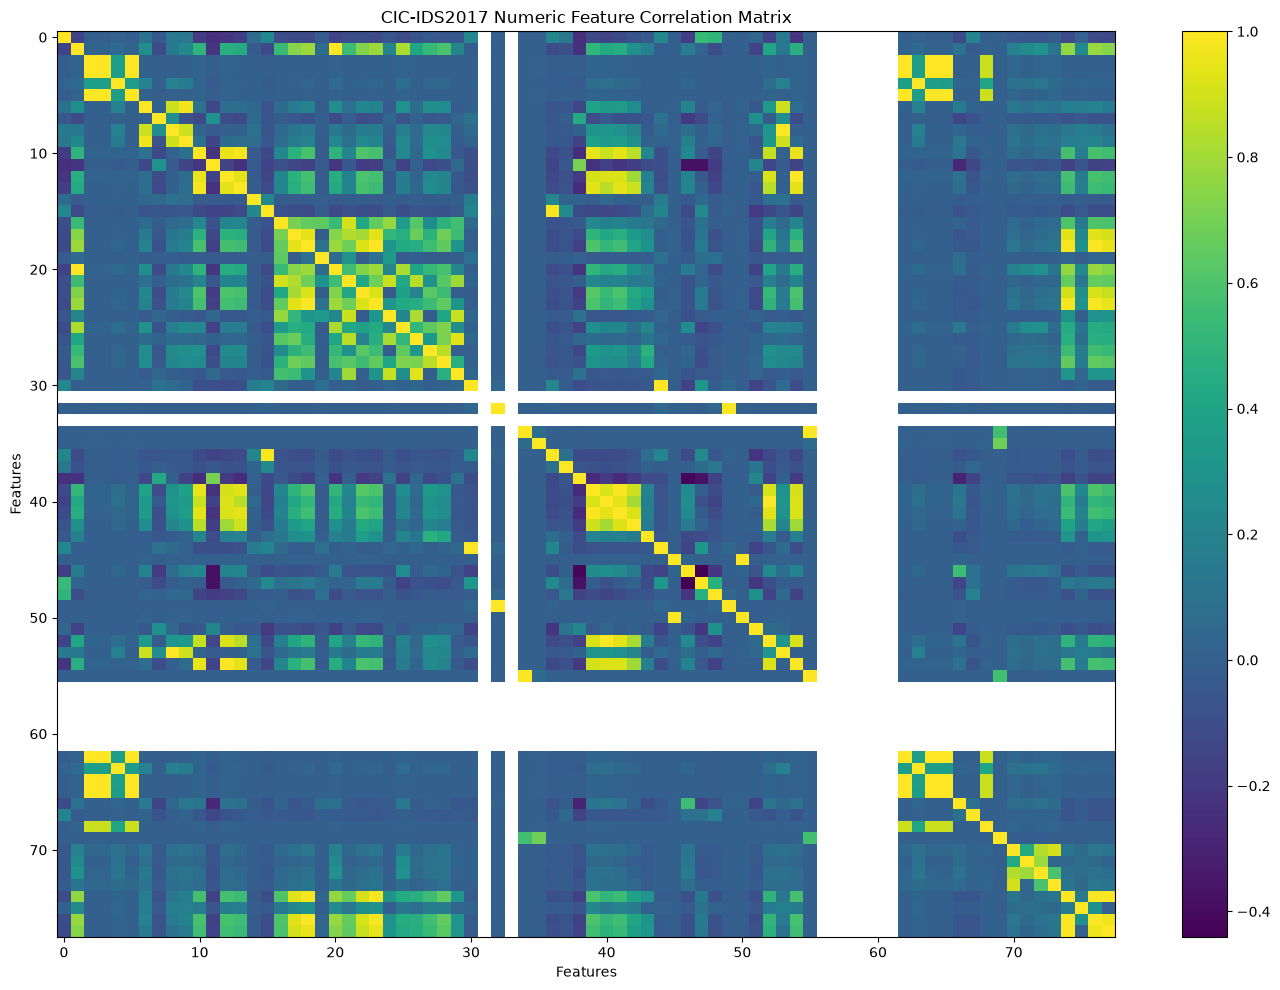

In [36]:
plt.figure(figsize=(14,10))

plt.imshow(correlation, aspect="auto")
plt.colorbar()

plt.title("CIC-IDS2017 Numeric Feature Correlation Matrix")
plt.xlabel("Features")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

## 9. Final Feature-Quality Report

In [39]:
feature_report = pd.DataFrame(index=data.columns)

feature_report["dtype"] = data.dtypes.astype(str)
feature_report["unique_values"] = data.nunique(dropna=False)
feature_report["missing_count"] = data.isna().sum()
feature_report["missing_percentage"] = data.isna().sum() / len(data) * 100

feature_report["is_numeric"] = data.dtypes.apply(
    lambda x: pd.api.types.is_numeric_dtype(x)
)

### Numeric Metrics

In [40]:
feature_report["inf_count"] = 0
feature_report["zero_percentage"] = np.nan
feature_report["skewness"] = np.nan

for col in numeric_data.columns:
    feature_report.loc[col, "inf_count"] = np.isinf(
        numeric_data[col]
    ).sum()

    feature_report.loc[col, "zero_percentage"] = (
        numeric_data[col] == 0
    ).mean() * 100

    feature_report.loc[col, "skewness"] = numeric_data[col].skew()

c:\Coding Stuff\CIC-Dataset-Analysis\.venv\Lib\site-packages\pandas\core\nanops.py:1275: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean
c:\Coding Stuff\CIC-Dataset-Analysis\.venv\Lib\site-packages\pandas\core\nanops.py:1275: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


### Flags

In [41]:
feature_report["constant"] = (
    feature_report["unique_values"] == 1
)

feature_report["near_constant"] = (
    feature_report["zero_percentage"] >= 99.9
)

### Write to file

In [42]:
feature_report.to_csv(
    OUTPUT_DIR / "feature_quality_summary.csv"
)

print("Saved feature quality report.")

Saved feature quality report.


### Save other reports

In [49]:
schema_df.to_csv(
    OUTPUT_DIR / "schema_consistency_report.csv",
    index=False
)

missing_summary.to_csv(
    OUTPUT_DIR / "missing_value_summary.csv",
    index=True
)

inf_summary.to_csv(
    OUTPUT_DIR / "infinite_value_summary.csv",
    index=True
)

high_corr.to_csv(
    OUTPUT_DIR / "high_correlation_pairs.csv",
    index=False
)

near_constant_df.to_csv(
    OUTPUT_DIR / "near_constant_features.csv",
    index=False
)

## 10. Conclusions

### Key Findings

**1. Dataset Structure**
- The combined CIC-IDS2017 dataset consists 2,830,743 records across 79 columns.
- All eight source files share a consistent schema and column ordering.
- Minor column-name whitespace was identified and normalized after combining the files.

**2. Missing Values**
    - Missing values are highly limited, with only `Flow Bytes/s` containing missing observations.
    - A total of 1,358 records **(0.048%)** contain a missing value in this feature.

**3. Infinite Values**
- Infinite values occur in the rate-based features `Flow Packets/s` and `Flow Bytes/s`.
- `Flow Packets/s` contains 2,867 infinite values **(0.01013%)**, while `Flow Bytes/s` contains 1,509 **(0.0533%)**.
- These values require treatment during later preprocessing because they can interfere with statistical calculations and machine-learning algorithms.

**4. Duplicate Records**
- 308,381 excat duplicate occurences were identified, representing approximatly **10.89%** of the complete dataset.
- A total of 403,550 rows participate in duplicate groups, corresponding to 95,510 distinct duplicate groups.
- Duplicate records are concentrated particularly along the `BENIGN`, `PortScan` and `DoS Hulk` classes.
- The presence of substantial duplication should therefore be considered when designing the preprocessing and model-evaluation strategy.

**5. Constant and near-constant features**
- Eight features are constant across the combined dataset.
- Several additional features are near-constant, with at least 99.9% of their observations sharing the same value.
- These observations are candidates for removal or further investigation during a later feature-selection or preprocessing stage.

**6. Feature distributions**
- Several numerical features exhibit substantial skewness and extreme values.
- A smaller number of features contain unusual negative values despite generally positive-valued distributions. These observations should be considered during later data-validation and preprocessing steps rather than being removed at this stage.

**7. Feature redundancy**
- Multiple feature pairs exhibit very high or perfect correlation (`|r| >= 0.95`).
- This indicates substantial redundancy among some CIC-IDS2017 features and suggests that feature-selection or dimensionality-reduction techniques may be useful during later modelling.

### Overall Assessment

CIC-IDS2017 has a largely consistent schema and very limited missing data, but the dataset also contains substantial duplicate records, infinite values, low-variance features, extreme observations, and highly redundant features. These characteristics are important considerations for subsquent preprocessing, feature selection and model evaluation.

No records or features were removed or transformed in this notebook. The identified data-quality issues are retained as findings and will be addressed only when the preprocessing strategy is established in the later stages of analysis.